In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

# Load data
data = pd.read_csv("Student_Performance.csv")

# Clean column names
data.columns = data.columns.str.strip().str.replace(" ", "_")

print(data.columns)  # check

# Convert categorical
data['Extracurricular_Activities'] = data['Extracurricular_Activities'].map({
    'Yes': 1,
    'No': 0
})

# Features & target
X = data[['Hours_Studied', 'Sleep_Hours', 'Extracurricular_Activities']]
y = data['Performance_Index']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Save
joblib.dump(model, "model.pkl")

print("✅ Model trained and saved!")

Index(['Hours_Studied', 'Previous_Scores', 'Extracurricular_Activities',
       'Sleep_Hours', 'Sample_Question_Papers_Practiced', 'Performance_Index'],
      dtype='str')
✅ Model trained and saved!


In [17]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.14720521456218072
MAE: 15.387650945511776


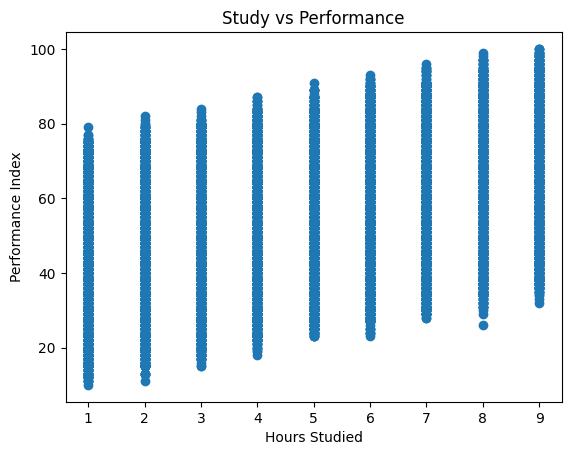

In [16]:
import matplotlib.pyplot as plt

plt.scatter(data['Hours_Studied'], data['Performance_Index'])
plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")
plt.title("Study vs Performance")
plt.show()